## Machine Learning Essentials Exercise 1
### 1 Exploring the Data

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images size: (1797, 8, 8)


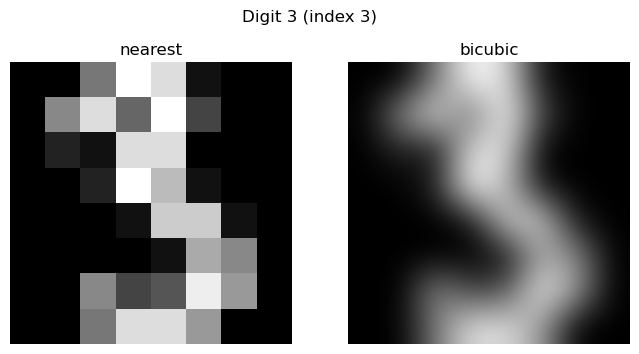

In [3]:
# load the dataset
digits = load_digits()

print(digits.keys())

# extracts data, images, target, target_names
data = digits['data']
images = digits['images']
target = digits['target']
target_names = digits['target_names']

# size of the images
images_size = images.shape

print(f'Images size: {images_size}')

# visualize one image of a 3
# find an idx where target == 3
digit = 3
idx = np.where(target == digit)[0][0] # returns the first index where target is matched
img = images[idx]

# check if img is a 2-D array
assert 2 == len(img.shape), 'The image is not a 2-D array'

# plot with the two interpolation methods('nearest' and 'bicubic')
plt.figure(figsize=(8, 4))
plt.gray()

plt.subplot(1, 2, 1)
plt.imshow(img, interpolation='nearest')
plt.title('nearest')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img, interpolation='bicubic')
plt.title('bicubic')
plt.axis('off')

plt.suptitle(f'Digit {digit} (index {idx})')
plt.show()

# filter the dataset for '3' and '9'
mask = np.isin(target, [3, 9])

data_39 = data[mask]
images_39 = images[mask]
target_39 = target[mask]

# split the filtered dataset into training set and testing set
X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    data_39,
    target_39,
    images_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)


### 2 Hand-crafted classifier

#### 2.1 Feature Construction

In [4]:
def features2d(X_train, y_train):
    # select the images that are 3 and 9
    mask3 = (y_train == 3)
    mask9 = (y_train == 9)

    img3s = X_train[mask3]
    img9s = X_train[mask9]

    if len(img3s) == 0 or len(img9s) == 0:
        raise ValueError("Training split must contain both classes 3 and 9.")

    # find the average of each pixel across all images
    avg_img3s = img3s.mean(axis=0)
    avg_img9s = img9s.mean(axis=0)

    # calculate the difference
    diff = np.abs(avg_img3s - avg_img9s)

    # find the two pixels position (indices) with biggest difference
    best_pixels_idx = np.argsort(diff)[::-1] # sort from biggest to smallest
    best_idx1 = best_pixels_idx[0]
    best_idx2 = best_pixels_idx[1]

    f1 = X_train[:, best_idx1]
    f2 = X_train[:, best_idx2]

    features = np.column_stack([f1, f2])
    
    return features
    
# build 2D features for the training and test sets.
training_features = features2d(X_train, y_train)
test_features = features2d(X_test, y_test)

#### 2.2 Scatter plot

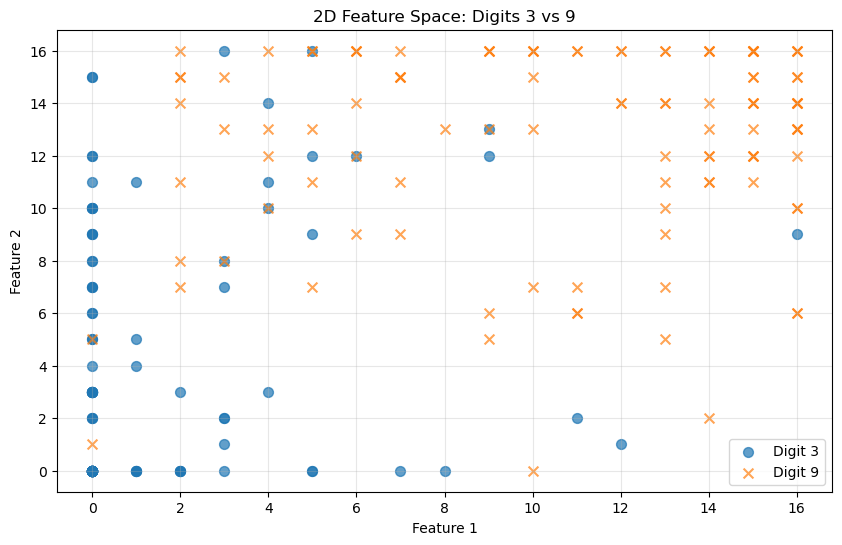

In [5]:
# Scatterplot of the 2D features
plt.figure(figsize=(10, 6))

# separate features by class
mask3 = (y_train == 3)
mask9 = (y_train == 9)

plt.scatter(training_features[mask3, 0], training_features[mask3, 1], label='Digit 3', alpha=0.7, s=50, marker='o')
plt.scatter(training_features[mask9, 0], training_features[mask9, 1], label='Digit 9', alpha=0.7, s=50, marker='x')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Feature Space: Digits 3 vs 9')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### 2.3 Decision rule

In [ ]:
def nearest_mean(training_features, training_labels,  test_features):
    # find  the mean for 3 and 9
    mean_3 = training_features[training_labels == -1].mean(axis=0)
    mean_9 = training_features[training_labels == 1].mean(axis=0)

    # for each test points, check which mean is closer
    predicted_labels = []

    for point in test_features:
        dist_to_3 = np.linalg.norm(point - mean_3)
        dist_to_9 = np.linalg.norm(point - mean_9)

        if (dist_to_3 < dist_to_9):
            predicted_labels.append(-1)  # closer to 3 so predict 3
        else:
            predicted_labels.append(1)  # closer to 9 so predict 9

    return np.array(predicted_labels)

# Use -1 for digit 3 and 1 for digit 9 in all later tasks.
y_train_binary = np.where(y_train == 3, -1, 1)
y_test_binary = np.where(y_test == 3, -1, 1)

# Predict labels using the nearest-mean rule.
predicted_train_labels = nearest_mean(training_features, y_train_binary, training_features)
predicted_test_labels = nearest_mean(training_features, y_train_binary, test_features)

def compute_error(predicted_labels, true_labels):
    wrong = np.sum(true_labels != predicted_labels)  # count mistakes
    total = len(true_labels)
    return wrong / total

training_error = compute_error(predicted_train_labels, y_train_binary)
test_error = compute_error(predicted_test_labels, y_test_binary)
print('Training error:', training_error)
print('Test error:', test_error)

Training error: 0.0967741935483871
Test error: 0.1095890410958904


#### 2.4 Visualize the decision regions

### 3 LDA
#### 3.1 Implement LDA training

#### 3.2 Implement LDA prediction

#### 3.3 Visualization

#### 3.4 Quantitative performance evaluation

### 4 SVM